<a href="https://colab.research.google.com/github/sabithakrishnan/edge-device-constraint-object-detection/blob/main/ojbect_detection_in_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics onnxruntime openvino opencv-python


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.1/96.1 kB 5.0 MB/s eta 0:00:00


In [2]:
import os

# A Raspberry Pi 4/5 has 4 native ARM cores.
# We restrict OpenMP and OpenVINO to utilize a strict low-power thread pool.
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["OPENVINO_NUM_THREADS"] = "4"

print("✓ Hardware throttling activated: Simulating a 4-core low-power CPU footprint.")


✓ Hardware throttling activated: Simulating a 4-core low-power CPU footprint.


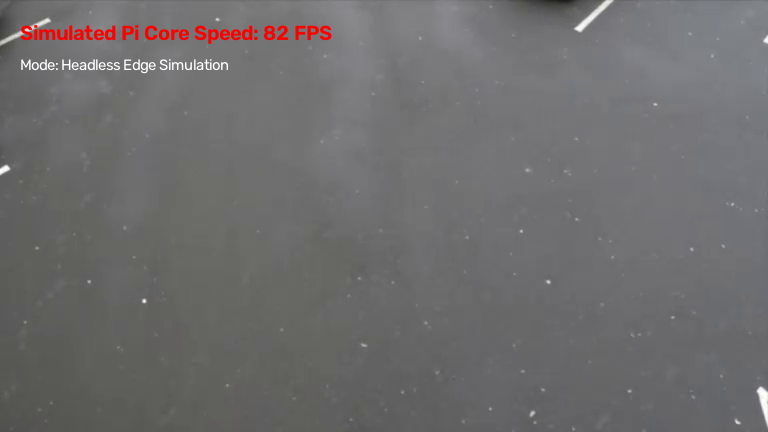


✓ Simulation stream complete.


In [5]:
import cv2
import time
import os
import numpy as np
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
from IPython.display import clear_output

VIDEO_PATH = "car-detection.mp4"


#Compile & Load OpenVINO-framework a Pi uses to accelerate CPU inference
OPENVINO_MODEL_PATH = "yolov8n_openvino_model/"
if not os.path.exists(OPENVINO_MODEL_PATH):
    base_model = YOLO("yolov8n.pt")
    base_model.export(format="openvino", half=True) # FP16 compression for edge CPUs

model = YOLO(OPENVINO_MODEL_PATH, task="detect")
#Processing video streams
cap = cv2.VideoCapture(VIDEO_PATH)
frame_count = 0
SKIP_FRAMES = 3  # Core Edge Concept: Process every 3rd frame to survive on low power

while cap.isOpened():
    start_time = time.time()
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    time.sleep(0.01)

    if frame_count % SKIP_FRAMES == 0:
        results = model.predict(source=frame, stream=True, conf=0.25, classes=[2, 7], verbose=False)
        for result in results:
            boxes = result.boxes.xyxy.cpu().numpy()
            for box in boxes:
                x1, y1, x2, y2 = map(int, box)
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # Calculate real-time simulated frame rate performance
    latency = time.time() - start_time
    simulated_fps = int(1.0 / latency)

    # Burn performance diagnostics onto the screen
    cv2.putText(frame, f"Simulated Pi Core Speed: {simulated_fps} FPS", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    cv2.putText(frame, f"Mode: Headless Edge Simulation", (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    # Render loop updates directly inside the browser cell outputs
    clear_output(wait=True)
    cv2_imshow(frame)

cap.release()
print("\n✓ Simulation stream complete.")